# Basic statistics with pyclesperanto
A common use case for image processing in the biology context is deriving statistics of segmented objects. clEsperanto offers a function for that: [labels_statistics](https://clij.github.io/clij2-docs/reference_statisticsOfLabelledPixels).

In [1]:
import pyclesperanto as cle

from skimage.io import imread
import numpy as np

# initialize GPU
cle.select_device("TX")

(OpenCL) Apple M5 Max (OpenCL 1.2)
	Vendor:                      Apple
	Driver Version:              1.2 1.0
	Device Type:                 GPU
	Compute Units:               40
	Global Memory Size:          53084 MB
	Local Memory Size:           0 MB
	Maximum Buffer Size:         9953 MB
	Max Clock Frequency:         1000 MHz
	Image Support:               Yes

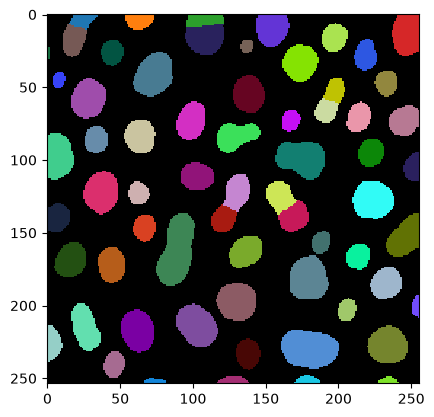

In [2]:
# load data
image = imread('https://samples.fiji.sc/blobs.png').squeeze()

# segment the image
labels = cle.voronoi_otsu_labeling(image, spot_sigma=3.5)
cle.imshow(labels, labels=True)

## Deriving basic statistics of labelled objects

With this label image, it is possible to compute various properties and values. For that we can rely on two functions: `labels_statistics` and `labels_neighbor_statistics`.

The first one, `labels_statistics`, is an equivalent to [scikit-image regionprops](https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops) but does not propose exactly the same quantification. Here, we will focus only on GPU-compatible quantifications.
The function will take a label image and an optional intensity image to compute several quantification.

In [3]:
statistics = cle.labels_statistics(labels, image)
print(statistics.keys())

dict_keys(['mean_max_distance_to_centroid_ratio', 'sum_distance_to_centroid', 'centroid_z', 'max_distance_to_mass_center', 'sum_z', 'centroid_y', 'max_distance_to_centroid', 'centroid_x', 'mean_distance_to_centroid', 'sum_x', 'sum_intensity_times_x', 'mean_max_distance_to_mass_center_ratio', 'sum_intensity', 'area', 'bbox_depth', 'mean_distance_to_mass_center', 'bbox_width', 'bbox_max_z', 'mass_center_y', 'sum_intensity_times_y', 'bbox_height', 'bbox_max_y', 'bbox_max_x', 'sum_y', 'mass_center_z', 'mean_intensity', 'bbox_min_z', 'sum_intensity_times_z', 'max_intensity', 'bbox_min_y', 'standard_deviation_intensity', 'mass_center_x', 'bbox_min_x', 'sum_distance_to_mass_center', 'min_intensity', 'label'])


We can use [pandas](https://pandas.pydata.org/) to nicely organise and process that kind of tabular data. 

In [4]:
import pandas as pd

In [12]:
table = pd.DataFrame(statistics)
table.head()

,mean_max_distance_to_centroid_ratio,sum_distance_to_centroid,centroid_z,max_distance_to_mass_center,sum_z,centroid_y,max_distance_to_centroid,centroid_x,mean_distance_to_centroid,sum_x,...,bbox_min_z,sum_intensity_times_z,max_intensity,bbox_min_y,standard_deviation_intensity,mass_center_x,bbox_min_x,sum_distance_to_mass_center,min_intensity,label
0,2.152889,678.573486,0.0,10.567422,0.0,3.935714,10.434954,24.335714,4.846953,3407.0,...,0.0,0.0,232.0,0.0,29.200169,24.170666,15.0,678.650940,112.0,1.0
1,1.989150,1000.747314,0.0,11.036123,0.0,4.252747,10.937561,63.076923,5.498611,11480.0,...,0.0,0.0,224.0,0.0,20.977858,63.218643,53.0,1001.514343,128.0,2.0
2,1.942624,1410.799805,0.0,13.370183,0.0,3.689320,13.304141,107.898056,6.848543,22227.0,...,0.0,0.0,240.0,0.0,25.941515,107.846832,96.0,1410.734985,120.0,3.0
3,1.838254,4084.938232,0.0,15.264709,0.0,13.487395,15.775537,246.817230,8.581803,117485.0,...,0.0,0.0,248.0,0.0,29.704020,247.138931,237.0,4091.146729,120.0,4.0
4,1.729956,3468.437256,0.0,13.623448,0.0,9.826087,13.730536,154.409607,7.936927,67477.0,...,0.0,0.0,248.0,0.0,36.976151,154.387878,144.0,3469.133545,112.0,5.0


The second function, `labels_neighbor_statistics`, works the same way but focus on neighbor topology, e.g. how many object are touching the label, how close is the nearest neighbor, how many object in a radious of `r`, etc.

In [13]:
nei_statistics = cle.labels_neighbors_statistics(labels)
nei_table = pd.DataFrame(nei_statistics)
nei_table.head()


,maximum_touch_portion_dilated_r_10,minimum_touch_portion_dilated_r_10,maximum_touch_count_dilated_r_10,minimum_touch_count_dilated_r_10,maximum_touch_portion_dilated_r_5,max_min_distance_ratio_of_touching_neighbors,minimum_touch_portion_dilated_r_5,minimum_touch_count_dilated_r_5,average_distance_of_touching_neighbors_dilated_r_5,touching_neighbor_count_dilated_r_10,...,standard_deviation_touch_portion,maximum_distance_of_n2_nearest_neighbors,maximum_distance_of_n1_nearest_neighbors,label,proximal_neighbor_count_d160,proximal_neighbor_count_d80,proximal_neighbor_count_d40,average_distance_of_n5_nearest_neighbors,proximal_neighbor_count_d20,maximum_distance_of_touching_neighbors
0,0.639344,0.131148,39.0,8.0,0.607143,1.0,0.607143,34.0,17.582169,3.0,...,0.122222,30.055647,15.005315,1.0,25.0,7.0,4.0,32.147255,1.0,15.005315
1,0.387500,0.100000,31.0,8.0,0.000000,NaN,0.800000,44.0,0.000000,3.0,...,0.000000,38.474907,28.597305,2.0,32.0,12.0,3.0,39.523720,0.0,0.000000
2,0.906250,0.906250,58.0,58.0,0.800000,1.0,0.800000,44.0,15.249834,1.0,...,0.108696,34.394363,12.899422,3.0,38.0,9.0,2.0,38.059307,1.0,12.899422
3,0.436620,0.352113,31.0,25.0,0.000000,NaN,0.800000,44.0,0.000000,2.0,...,0.000000,36.260948,31.601971,4.0,26.0,8.0,2.0,47.917427,0.0,0.000000
4,0.427273,0.363636,47.0,40.0,0.288889,NaN,0.244444,22.0,25.493607,2.0,...,0.000000,30.423452,21.022678,5.0,38.0,11.0,2.0,37.596275,0.0,0.000000


`labels_neighbors_statistics` takes a list of distances and values which define the how far are we looking around each label, allowing a wide scale of analysis:

In [8]:
cle.labels_neighbors_statistics?

Signature:
cle.labels_neighbors_statistics(
    label: Union[numpy.ndarray, pyclesperanto._array.Array],
    proximal_distances: list = [10, 20, 40, 80, 160],
    nearest_neighbor_ns: list = [1, 2, 3, 4, 5, 6, 7, 8, 10, 20],
    dilation_radii: list = [5, 10],
    include_background: bool = False,
    device: Optional[pyclesperanto._core.Device] = None,
) -> dict
Docstring:
Computes touching, distance-based, and neighborhood statistics of labels and
their neighbors. For each label in the input label image, this function computes
statistics of its surrounding labels within specified proximal distances. The
statistics include the count of neighboring labels, their distances, if they are
touching, how many pixels they share on the boundary, etc. Important: This
expect an isotropic image with isotropic pixel spacing.

Parameters
----------
label: Image 
    Input label image.
proximal_distances: list (= [10, 20, 40, 80, 160])
    Proximal distances list for analysis.
nearest_neighbor_ns: l